In [35]:
gaia_lamost_sample = crossmatched_by_id[final_columns + ["id_match_sep_arcsec"]].copy()

output_path = DATA_PROCESSED / "gaia_lamost_crossmatched_sample.csv"

gaia_lamost_sample.to_csv(output_path, index=False)

output_path, gaia_lamost_sample.shape

(PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_crossmatched_sample.csv'),
 (138, 29))

In [34]:
id_matched_gaia_coord = SkyCoord(
    ra=crossmatched_by_id["ra_gaia"].values * u.deg,
    dec=crossmatched_by_id["dec_gaia"].values * u.deg,
    frame="icrs"
)

id_matched_lamost_coord = SkyCoord(
    ra=crossmatched_by_id["ra_lamost"].values * u.deg,
    dec=crossmatched_by_id["dec_lamost"].values * u.deg,
    frame="icrs"
)

id_match_sep = id_matched_gaia_coord.separation(id_matched_lamost_coord)

crossmatched_by_id["id_match_sep_arcsec"] = id_match_sep.arcsec

crossmatched_by_id["id_match_sep_arcsec"].describe()

count    138.000000
mean       0.154590
std        0.129280
min        0.015673
25%        0.082586
50%        0.125609
75%        0.171855
max        0.831527
Name: id_match_sep_arcsec, dtype: float64

In [33]:
gaia_coord = SkyCoord(
    ra=gaia_region_sample["ra"].values * u.deg,
    dec=gaia_region_sample["dec"].values * u.deg,
    frame="icrs"
)

lamost_coord = SkyCoord(
    ra=lamost_clean["ra"].values * u.deg,
    dec=lamost_clean["dec"].values * u.deg,
    frame="icrs"
)

idx, sep2d, _ = gaia_coord.match_to_catalog_sky(lamost_coord)

for radius in [0.5, 1.0, 2.0, 3.0]:
    n_match = np.sum(sep2d < radius * u.arcsec)
    print(f"{radius:3.1f} arcsec: {n_match} matches")

0.5 arcsec: 120 matches
1.0 arcsec: 123 matches
2.0 arcsec: 123 matches
3.0 arcsec: 124 matches


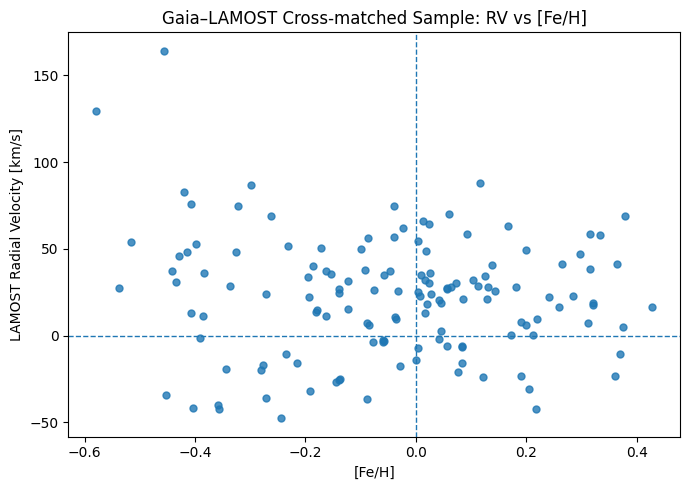

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_rv_vs_feh.png')

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    gaia_lamost_sample["feh"],
    gaia_lamost_sample["rv"],
    s=25,
    alpha=0.8
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("[Fe/H]")
plt.ylabel("LAMOST Radial Velocity [km/s]")
plt.title("Gaia–LAMOST Cross-matched Sample: RV vs [Fe/H]")

plt.tight_layout()

rv_feh_path = FIGURES / "gaia_lamost_rv_vs_feh.png"
plt.savefig(rv_feh_path, dpi=200)

plt.show()

rv_feh_path

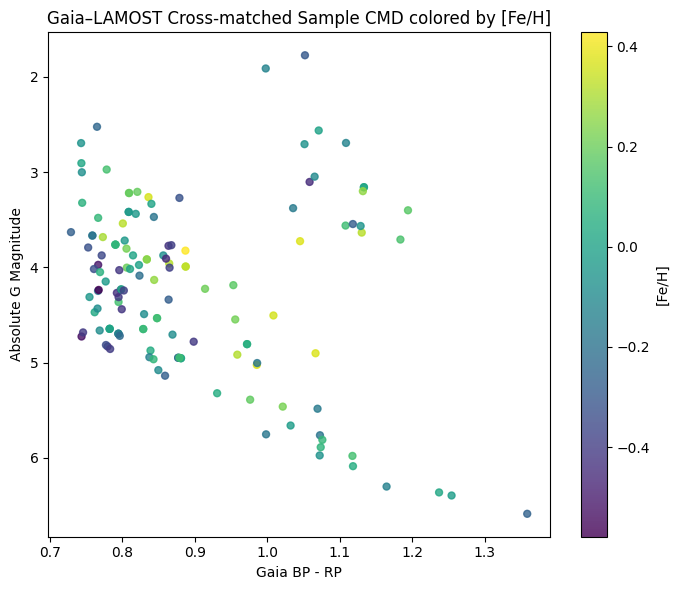

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_cmd_colored_by_feh.png')

In [31]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    gaia_lamost_sample["bp_rp"],
    gaia_lamost_sample["absolute_g_mag"],
    c=gaia_lamost_sample["feh"],
    s=25,
    alpha=0.8
)

plt.gca().invert_yaxis()

plt.xlabel("Gaia BP - RP")
plt.ylabel("Absolute G Magnitude")
plt.title("Gaia–LAMOST Cross-matched Sample CMD colored by [Fe/H]")

cbar = plt.colorbar(scatter)
cbar.set_label("[Fe/H]")

plt.tight_layout()

cmd_feh_path = FIGURES / "gaia_lamost_cmd_colored_by_feh.png"
plt.savefig(cmd_feh_path, dpi=200)

plt.show()

cmd_feh_path

In [30]:
gaia_lamost_sample[[
    "distance_pc",
    "absolute_g_mag",
    "bp_rp",
    "teff",
    "logg",
    "feh",
    "rv",
    "snrg"
]].describe()

,distance_pc,absolute_g_mag,bp_rp,teff,logg,feh,rv,snrg
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000,138.000000
mean,755.985197,4.221372,0.892865,5587.761014,4.224000,-0.043145,21.932536,82.946232
std,621.555787,0.906065,0.136587,341.573141,0.308254,0.233339,34.398677,30.843526
min,99.120297,1.773872,0.729041,4624.900000,3.510000,-0.579000,-47.740000,50.140000
25%,395.356707,3.642762,0.792865,5317.875000,4.022000,-0.192500,-1.715000,62.210000
50%,581.084747,4.167531,0.841450,5697.120000,4.276000,-0.026000,23.855000,77.960000
75%,854.003792,4.799242,0.985701,5849.592500,4.420250,0.115750,40.662500,90.317500
max,4434.735109,6.586294,1.358320,5998.170000,4.810000,0.428000,164.260000,254.900000


In [29]:
output_path = DATA_PROCESSED / "gaia_lamost_crossmatched_sample.csv"

gaia_lamost_sample.to_csv(output_path, index=False)

output_path, gaia_lamost_sample.shape

(PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_crossmatched_sample.csv'),
 (138, 28))

In [28]:
final_columns = [
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "parallax",
    "parallax_over_error",
    "pmra",
    "pmdec",
    "phot_g_mean_mag",
    "bp_rp",
    "ruwe",
    "distance_pc",
    "absolute_g_mag",
    "obsid",
    "designation",
    "gaia_source_id",
    "ra_lamost",
    "dec_lamost",
    "snrg",
    "class",
    "subclass",
    "teff",
    "teff_err",
    "logg",
    "logg_err",
    "feh",
    "feh_err",
    "rv",
    "rv_err",
]

gaia_lamost_sample = crossmatched_by_id[final_columns].copy()

gaia_lamost_sample.head()

,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,...,class,subclass,teff,teff_err,logg,logg_err,feh,feh_err,rv,rv_err
0,3084445095932542080,121.282228,0.512150,4.631884,188.207565,-15.153145,7.702148,11.034749,0.794672,1.306483,...,STAR,G3,5803.46,33.10,4.258,0.044,0.126,0.025,34.19,5.32
1,3084578720955039744,121.989146,0.908265,0.533697,17.030481,-2.469817,-4.160283,15.088555,1.045016,1.016637,...,STAR,K1,5302.44,25.63,4.460,0.036,0.376,0.022,4.91,3.42
2,3084637098150125952,120.988289,1.186262,0.775818,32.108326,-5.144803,-2.841027,14.425479,0.814630,0.994611,...,STAR,G2,5875.14,31.16,4.197,0.042,0.010,0.024,35.19,4.74
3,3084669224505393280,121.516145,1.450176,1.684938,98.572060,4.752070,-2.820532,12.842078,0.822827,1.024657,...,STAR,G4,5802.57,30.05,4.479,0.042,0.003,0.025,-7.17,4.05
4,3083675540871959552,121.939753,0.275229,2.397850,169.145065,-13.858935,-15.213946,10.664133,1.070729,1.062962,...,STAR,G5,5119.94,27.59,3.534,0.038,0.000,0.022,-14.13,3.96


In [27]:
crossmatched_by_id.columns.tolist()

['source_id',
 'ra_gaia',
 'dec_gaia',
 'parallax',
 'parallax_over_error',
 'pmra',
 'pmdec',
 'phot_g_mean_mag',
 'bp_rp',
 'ruwe',
 'distance_pc',
 'absolute_g_mag',
 'source_id_str',
 'obsid',
 'designation',
 'gaia_source_id',
 'ra_lamost',
 'dec_lamost',
 'snrg',
 'class',
 'subclass',
 'teff',
 'teff_err',
 'logg',
 'logg_err',
 'feh',
 'feh_err',
 'rv',
 'rv_err',
 'gaia_source_id_str']

In [26]:
crossmatched_by_id.head()

,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,...,subclass,teff,teff_err,logg,logg_err,feh,feh_err,rv,rv_err,gaia_source_id_str
0,3084445095932542080,121.282228,0.512150,4.631884,188.207565,-15.153145,7.702148,11.034749,0.794672,1.306483,...,G3,5803.46,33.10,4.258,0.044,0.126,0.025,34.19,5.32,3084445095932542080
1,3084578720955039744,121.989146,0.908265,0.533697,17.030481,-2.469817,-4.160283,15.088555,1.045016,1.016637,...,K1,5302.44,25.63,4.460,0.036,0.376,0.022,4.91,3.42,3084578720955039744
2,3084637098150125952,120.988289,1.186262,0.775818,32.108326,-5.144803,-2.841027,14.425479,0.814630,0.994611,...,G2,5875.14,31.16,4.197,0.042,0.010,0.024,35.19,4.74,3084637098150125952
3,3084669224505393280,121.516145,1.450176,1.684938,98.572060,4.752070,-2.820532,12.842078,0.822827,1.024657,...,G4,5802.57,30.05,4.479,0.042,0.003,0.025,-7.17,4.05,3084669224505393280
4,3083675540871959552,121.939753,0.275229,2.397850,169.145065,-13.858935,-15.213946,10.664133,1.070729,1.062962,...,G5,5119.94,27.59,3.534,0.038,0.000,0.022,-14.13,3.96,3083675540871959552


In [25]:
gaia_region_sample["source_id_str"] = gaia_region_sample["source_id"].astype(str)
lamost_clean["gaia_source_id_str"] = lamost_clean["gaia_source_id"].astype(str)

crossmatched_by_id = gaia_region_sample.merge(
    lamost_clean,
    left_on="source_id_str",
    right_on="gaia_source_id_str",
    how="inner",
    suffixes=("_gaia", "_lamost")
)

crossmatched_by_id.shape

(138, 30)

In [24]:
gaia_region_features_path = DATA_PROCESSED / "gaia_dr3_lamost_region_with_features.csv"

gaia_region_sample.to_csv(gaia_region_features_path, index=False)

gaia_region_features_path

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_dr3_lamost_region_with_features.csv')

In [ ]:
gaia_region_sample["distance_pc"] = 1000.0 / gaia_region_sample["parallax"]

gaia_region_sample["absolute_g_mag"] = (
    gaia_region_sample["phot_g_mean_mag"]
    - 5 * np.log10(gaia_region_sample["distance_pc"])
    + 5
)

gaia_region_sample[[
    "source_id",
    "ra",
    "dec",
    "parallax",
    "distance_pc",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "bp_rp"
]].head()

,source_id,ra,dec,parallax,distance_pc,phot_g_mean_mag,absolute_g_mag,bp_rp
0,3083613173648554368,121.801112,-0.028646,0.702429,1423.631028,17.674265,6.907278,1.584265
1,3083614999014012544,121.898525,0.012195,0.750842,1331.837723,16.097347,5.475091,0.978217
2,3083616167244159488,121.758082,-0.015969,1.280516,780.935062,15.571331,6.108256,1.120037
3,3083616201603894784,121.770104,-0.014338,2.151649,464.759754,17.809660,9.473517,2.443287
4,3083616613920742272,121.773870,0.034066,0.650332,1537.676158,16.634268,5.699943,1.037487


In [22]:
gaia_region_path = DATA_RAW / "gaia_dr3_lamost_region_sample.csv"

gaia_region_sample.to_csv(gaia_region_path, index=False)

gaia_region_path

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_lamost_region_sample.csv')

In [21]:
gaia_region_sample.head()

,source_id,ra,dec,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe
0,3083613173648554368,121.801112,-0.028646,0.702429,5.821536,-6.251838,-0.005693,17.674265,1.584265,1.030560
1,3083614999014012544,121.898525,0.012195,0.750842,16.836996,-3.682788,-0.288453,16.097347,0.978217,0.983945
2,3083616167244159488,121.758082,-0.015969,1.280516,34.069893,-0.396997,-7.520007,15.571331,1.120037,1.002311
3,3083616201603894784,121.770104,-0.014338,2.151649,17.809986,-37.568198,-1.028853,17.809660,2.443287,0.975237
4,3083616613920742272,121.773870,0.034066,0.650332,11.453491,-8.788067,0.141903,16.634268,1.037487,0.987837


In [20]:
from astroquery.gaia import Gaia

query = f"""
SELECT TOP 20000
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN {gaia_region["ra_min"]} AND {gaia_region["ra_max"]}
  AND dec BETWEEN {gaia_region["dec_min"]} AND {gaia_region["dec_max"]}
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4
"""

job = Gaia.launch_job_async(query)
gaia_region_sample = job.get_results().to_pandas()

gaia_region_sample.shape

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).
INFO: Query finished. [astroquery.utils.tap.core]


(16451, 10)

In [19]:
margin_deg = 0.05

gaia_region = {
    "ra_min": ra_min - margin_deg,
    "ra_max": ra_max + margin_deg,
    "dec_min": dec_min - margin_deg,
    "dec_max": dec_max + margin_deg,
}

gaia_region

{'ra_min': np.float64(119.952082),
 'ra_max': np.float64(122.039136),
 'dec_min': np.float64(-0.048147),
 'dec_max': np.float64(2.0454369999999997)}

In [18]:
ra_min = lamost_clean["ra"].min()
ra_max = lamost_clean["ra"].max()
dec_min = lamost_clean["dec"].min()
dec_max = lamost_clean["dec"].max()

ra_min, ra_max, dec_min, dec_max

(np.float64(120.002082),
 np.float64(121.989136),
 np.float64(0.001853),
 np.float64(1.995437))

In [17]:
lamost_clean[numeric_cols].describe()

,ra,dec,snrg,teff,teff_err,logg,logg_err,feh,feh_err,rv,rv_err
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,121.000018,1.097839,86.944439,5588.553209,31.343957,4.244064,0.043775,-0.055273,0.025818,21.982139,4.384385
std,0.580839,0.607391,37.741079,337.903241,8.844608,0.314798,0.012645,0.228208,0.007753,36.620816,1.194394
min,120.002082,0.001853,50.140000,4624.900000,17.080000,3.510000,0.021000,-0.581000,0.009000,-47.740000,2.830000
25%,120.494502,0.563757,61.675000,5347.590000,25.840000,4.034000,0.036000,-0.195000,0.021000,-3.125000,3.715000
50%,120.995300,1.239183,77.960000,5694.270000,29.980000,4.297000,0.042000,-0.036000,0.025000,23.770000,4.120000
75%,121.466850,1.600547,95.560000,5859.855000,35.010000,4.462500,0.049000,0.089500,0.029000,40.525000,4.875000
max,121.989136,1.995437,266.540000,5998.170000,99.620000,4.810000,0.139000,0.428000,0.081000,164.260000,13.870000


In [16]:
missing_summary = (
    lamost_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)

missing_summary["missing_fraction"] = missing_summary["missing_count"] / len(lamost_clean)

missing_summary

,missing_count,missing_fraction
obsid,0,0.0
designation,0,0.0
gaia_source_id,0,0.0
ra,0,0.0
dec,0,0.0
snrg,0,0.0
class,0,0.0
subclass,0,0.0
teff,0,0.0
teff_err,0,0.0


In [15]:
numeric_cols = [
    "ra",
    "dec",
    "snrg",
    "teff",
    "teff_err",
    "logg",
    "logg_err",
    "feh",
    "feh_err",
    "rv",
    "rv_err",
]

for col in numeric_cols:
    lamost_clean[col] = pd.to_numeric(lamost_clean[col], errors="coerce")

lamost_clean[numeric_cols].describe()

,ra,dec,snrg,teff,teff_err,logg,logg_err,feh,feh_err,rv,rv_err
count,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000,187.000000
mean,121.000018,1.097839,86.944439,5588.553209,31.343957,4.244064,0.043775,-0.055273,0.025818,21.982139,4.384385
std,0.580839,0.607391,37.741079,337.903241,8.844608,0.314798,0.012645,0.228208,0.007753,36.620816,1.194394
min,120.002082,0.001853,50.140000,4624.900000,17.080000,3.510000,0.021000,-0.581000,0.009000,-47.740000,2.830000
25%,120.494502,0.563757,61.675000,5347.590000,25.840000,4.034000,0.036000,-0.195000,0.021000,-3.125000,3.715000
50%,120.995300,1.239183,77.960000,5694.270000,29.980000,4.297000,0.042000,-0.036000,0.025000,23.770000,4.120000
75%,121.466850,1.600547,95.560000,5859.855000,35.010000,4.462500,0.049000,0.089500,0.029000,40.525000,4.875000
max,121.989136,1.995437,266.540000,5998.170000,99.620000,4.810000,0.139000,0.428000,0.081000,164.260000,13.870000


In [14]:
lamost_clean = lamost[list(selected_cols.values())].copy()
lamost_clean = lamost_clean.rename(
    columns={v: k for k, v in selected_cols.items()}
)

lamost_clean.head()

,obsid,designation,gaia_source_id,ra,dec,snrg,class,subclass,teff,teff_err,logg,logg_err,feh,feh_err,rv,rv_err
0,115109094,J080011.76+004925.7,3084703137567209344,120.04901,0.823831,137.99,STAR,G1,5876.56,40.85,4.285,0.055,-0.047,0.031,37.09,6.57
1,115111043,J080012.30+013601.9,3084815974947636480,120.05127,1.600547,137.85,STAR,G3,5964.22,28.97,4.464,0.039,0.057,0.022,26.70,4.66
2,115112029,J080154.61+012115.5,3084751584798365184,120.47757,1.354309,54.19,STAR,G2,5924.90,21.31,4.068,0.030,-0.154,0.018,35.49,2.87
3,115113113,J080402.11+002927.2,3084433413620685056,121.00881,0.490915,96.90,STAR,G6,5828.13,21.74,4.460,0.030,0.285,0.018,22.88,3.08
4,115312071,J080053.08+011034.0,3084719389723324416,120.22118,1.176120,81.19,STAR,F9,5747.09,29.98,4.560,0.042,0.083,0.025,-15.86,4.05


In [13]:
selected_cols = {
    "obsid": "combined_obsid",
    "designation": "combined_designation",
    "gaia_source_id": "combined_gaia_source_id",
    "ra": "combined_ra",
    "dec": "combined_dec",
    "snrg": "combined_snrg",
    "class": "combined_class",
    "subclass": "combined_subclass",
    "teff": "combined_teff",
    "teff_err": "combined_teff_err",
    "logg": "combined_logg",
    "logg_err": "combined_logg_err",
    "feh": "combined_feh",
    "feh_err": "combined_feh_err",
    "rv": "combined_rv",
    "rv_err": "combined_rv_err",
}

selected_cols

{'obsid': 'combined_obsid',
 'designation': 'combined_designation',
 'gaia_source_id': 'combined_gaia_source_id',
 'ra': 'combined_ra',
 'dec': 'combined_dec',
 'snrg': 'combined_snrg',
 'class': 'combined_class',
 'subclass': 'combined_subclass',
 'teff': 'combined_teff',
 'teff_err': 'combined_teff_err',
 'logg': 'combined_logg',
 'logg_err': 'combined_logg_err',
 'feh': 'combined_feh',
 'feh_err': 'combined_feh_err',
 'rv': 'combined_rv',
 'rv_err': 'combined_rv_err'}

In [11]:
lamost.info()

<class 'pandas.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   combined_obsid           187 non-null    int64  
 1   combined_designation     187 non-null    str    
 2   combined_obsdate         187 non-null    str    
 3   combined_lmjd            187 non-null    int64  
 4   combined_mjd             187 non-null    int64  
 5   combined_planid          187 non-null    str    
 6   combined_spid            187 non-null    int64  
 7   combined_fiberid         187 non-null    int64  
 8   combined_snru            187 non-null    float64
 9   combined_snrg            187 non-null    float64
 10  combined_snrr            187 non-null    float64
 11  combined_snri            187 non-null    float64
 12  combined_snrz            187 non-null    float64
 13  combined_class           187 non-null    str    
 14  combined_subclass        187 non-null

In [10]:
lamost.shape

(187, 27)

In [12]:
def find_columns(df, keywords):
    result = {}
    lower_cols = {col.lower(): col for col in df.columns}
    
    for key in keywords:
        matches = [original for lower, original in lower_cols.items() if key.lower() in lower]
        result[key] = matches
    
    return result


keywords = [
    "ra",
    "dec",
    "teff",
    "logg",
    "feh",
    "rv",
    "snr",
    "type",
    "class",
    "gaia",
    "source"
]

find_columns(lamost, keywords)

{'ra': ['combined_ra'],
 'dec': ['combined_dec'],
 'teff': ['combined_teff', 'combined_teff_err'],
 'logg': ['combined_logg', 'combined_logg_err'],
 'feh': ['combined_feh', 'combined_feh_err'],
 'rv': ['combined_rv_err', 'combined_rv'],
 'snr': ['combined_snru',
  'combined_snrg',
  'combined_snrr',
  'combined_snri',
  'combined_snrz'],
 'type': [],
 'class': ['combined_class', 'combined_subclass'],
 'gaia': ['combined_gaia_source_id'],
 'source': ['combined_gaia_source_id']}

In [9]:
lamost.columns.tolist()

['combined_obsid',
 'combined_designation',
 'combined_obsdate',
 'combined_lmjd',
 'combined_mjd',
 'combined_planid',
 'combined_spid',
 'combined_fiberid',
 'combined_snru',
 'combined_snrg',
 'combined_snrr',
 'combined_snri',
 'combined_snrz',
 'combined_class',
 'combined_subclass',
 'combined_z',
 'combined_gaia_source_id',
 'combined_ra',
 'combined_dec',
 'combined_feh',
 'combined_feh_err',
 'combined_logg',
 'combined_logg_err',
 'combined_rv_err',
 'combined_rv',
 'combined_teff',
 'combined_teff_err']

In [8]:
lamost_path = DATA_RAW / "lamost_dr9_afgk_sample.csv"

lamost = pd.read_csv(lamost_path, sep="|")
lamost.head()

,combined_obsid,combined_designation,combined_obsdate,combined_lmjd,combined_mjd,combined_planid,combined_spid,combined_fiberid,combined_snru,combined_snrg,...,combined_ra,combined_dec,combined_feh,combined_feh_err,combined_logg,combined_logg_err,combined_rv_err,combined_rv,combined_teff,combined_teff_err
0,115109094,J080011.76+004925.7,2013-01-28,56321,56320,GAC119S00V1,9,94,31.78,137.99,...,120.04901,0.823831,-0.047,0.031,4.285,0.055,6.57,37.09,5876.56,40.85
1,115111043,J080012.30+013601.9,2013-01-28,56321,56320,GAC119S00V1,11,43,38.94,137.85,...,120.05127,1.600547,0.057,0.022,4.464,0.039,4.66,26.70,5964.22,28.97
2,115112029,J080154.61+012115.5,2013-01-28,56321,56320,GAC119S00V1,12,29,13.51,54.19,...,120.47757,1.354309,-0.154,0.018,4.068,0.030,2.87,35.49,5924.90,21.31
3,115113113,J080402.11+002927.2,2013-01-28,56321,56320,GAC119S00V1,13,113,18.82,96.90,...,121.00881,0.490915,0.285,0.018,4.460,0.030,3.08,22.88,5828.13,21.74
4,115312071,J080053.08+011034.0,2013-01-28,56321,56320,GAC119S00V3,12,71,15.68,81.19,...,120.22118,1.176120,0.083,0.025,4.560,0.042,4.05,-15.86,5747.09,29.98


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u

PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

DATA_RAW, DATA_PROCESSED, FIGURES

(PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures'))

# 02 LAMOST Catalogue Exploration and Gaia–LAMOST Cross-match Planning

This notebook starts Milestone 2 of the Gaia–LAMOST Galactic Archaeology Project.

Goals:

1. Choose a suitable LAMOST catalogue
2. Load a small LAMOST sample
3. Inspect column names and data quality
4. Identify useful stellar parameters
5. Design the Gaia–LAMOST cross-match workflow
6. Build a first combined Gaia–LAMOST sample